# WanderWise: Predicting Your Perfect Getaway  
## A Hybrid Travel Destination Recommender System

**Dataset:** Traveler Trip Dataset from Kaggle  
**Project Type:** Recommender Systems / Data Science Project  
**Main Goal:** Recommend personalized travel destinations using traveler profile, budget, trip duration, accommodation preference, transportation preference, and destination-level historical patterns.

# 1. Problem Statement

Travel planning is a recommendation problem because travelers need to balance preference and feasibility. A destination may be attractive, but it may not be practical if it does not fit the user's budget, preferred trip duration, accommodation style, transportation mode, or travel timing.

This project answers the question:

> Given a traveler profile and trip preferences, which destinations are most suitable?

## Data Science Objective

Build a hybrid destination recommender system that ranks destinations using:

- content-based profile similarity
- budget fit
- trip duration fit
- accommodation-per-night fit
- accommodation and transportation preference match
- month similarity
- destination popularity
- age similarity

## Why Hybrid Recommendation?

The dataset does not contain explicit user ratings, clicks, bookings, or satisfaction outcomes. Because of this, pure collaborative filtering is not appropriate. The project instead uses a hybrid recommender that combines content similarity, numerical closeness scores, preference matching, and popularity confidence.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# 2. Load Dataset

Update `DATA_PATH` if your file is in a different folder. The notebook includes a small path search fallback so it can still work if the CSV is stored in the current directory, parent directory, or Kaggle input folder.

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "Travel details dataset.csv"

candidate_paths = [
    DATA_PATH,
    "./Travel details dataset.csv",
    "../input/travel-details-dataset/Travel details dataset.csv",
    "../input/Travel details dataset.csv",
    "/Users/wpmangapot/Desktop/WorkFolder/Projects/stat280_pml/notebooks/Project/Travel details dataset.csv",
]

resolved_path = None
for path in candidate_paths:
    if os.path.exists(path):
        resolved_path = path
        break

if resolved_path is None:
    raise FileNotFoundError(
        "CSV file not found. Please update DATA_PATH to the location of 'Travel details dataset.csv'."
    )

print("Using dataset:", resolved_path)
df_raw = pd.read_csv(resolved_path)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Using dataset: Travel details dataset.csv
Dataset shape: (139, 13)


,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [3]:
# ============================================================
# DATA AUDIT
# ============================================================

data_audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_count": df_raw.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(data_audit)

,dtype,missing_count,missing_pct,unique_count
Transportation type,object,3,2.16,9
Transportation cost,object,3,2.16,48
Destination,object,2,1.44,59
Start date,object,2,1.44,111
End date,object,2,1.44,125
Duration (days),float64,2,1.44,9
Traveler name,object,2,1.44,109
Traveler age,float64,2,1.44,29
Traveler gender,object,2,1.44,2
Traveler nationality,object,2,1.44,41


## Data Audit Interpretation

The audit checks missingness, data types, and unique values. The most important fields for this recommender are destination, start date, end date, duration, traveler age, accommodation cost, transportation cost, accommodation type, and transportation type.

Missing values are handled carefully because these fields directly affect the recommendation score.

In [4]:
# ============================================================
# CLEANING AND NORMALIZATION FUNCTIONS
# ============================================================

def clean_column_names(dataframe):
    """Convert column names into clean snake_case format."""
    df = dataframe.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.strip("_")
    )
    return df


def clean_money(value):
    """Convert money-like text into float."""
    if pd.isna(value):
        return np.nan
    value = str(value)
    value = re.sub(r"[^0-9.]", "", value)
    if value == "":
        return np.nan
    try:
        return float(value)
    except ValueError:
        return np.nan


def normalize_text(value):
    """Basic text normalization for matching."""
    if pd.isna(value):
        return "unknown"
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text if text else "unknown"


def title_case_destination(text):
    """Readable title-case destination formatting."""
    if pd.isna(text) or str(text).strip() == "":
        return "Unknown"
    return str(text).strip().title()


def normalize_country(country):
    """Standardize common country names and abbreviations."""
    if pd.isna(country):
        return "Unknown"

    c = normalize_text(country)

    country_map = {
        "usa": "United States",
        "us": "United States",
        "u s": "United States",
        "u s a": "United States",
        "united states of america": "United States",
        "united states": "United States",
        "america": "United States",
        "uk": "United Kingdom",
        "u k": "United Kingdom",
        "england": "United Kingdom",
        "united kingdom": "United Kingdom",
        "uae": "United Arab Emirates",
        "u a e": "United Arab Emirates",
        "united arab emirates": "United Arab Emirates",
        "aus": "Australia",
        "australia": "Australia",
        "thai": "Thailand",
        "thailand": "Thailand",
        "korea": "South Korea",
        "south korea": "South Korea",
        "republic of korea": "South Korea",
        "philippines": "Philippines",
        "the philippines": "Philippines",
    }

    return country_map.get(c, c.title())


def normalize_city(city):
    """Standardize common city variants."""
    if pd.isna(city):
        return "Unknown"

    c = normalize_text(city)

    city_map = {
        "nyc": "New York City",
        "new york": "New York City",
        "new york city": "New York City",
        "seoul": "Seoul",
        "sydney": "Sydney",
        "barcelona": "Barcelona",
        "tokyo": "Tokyo",
        "paris": "Paris",
        "london": "London",
        "bangkok": "Bangkok",
        "bali": "Bali",
        "dubai": "Dubai",
        "rome": "Rome",
        "singapore": "Singapore",
        "hong kong": "Hong Kong",
        "los angeles": "Los Angeles",
        "la": "Los Angeles",
    }

    return city_map.get(c, c.title())


def split_destination(value):
    """
    Split destination into city and country.
    Handles examples like:
    - New York City, USA
    - New York City, United States
    - Seoul
    - Seoul, South Korea
    """
    if pd.isna(value) or str(value).strip() == "":
        return pd.Series(["Unknown", "Unknown"])

    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)

    if "," in text:
        parts = [p.strip() for p in text.split(",") if p.strip()]
        city_raw = parts[0]
        country_raw = parts[-1] if len(parts) > 1 else "Unknown"
    else:
        city_raw = text
        country_raw = "Unknown"

    city = normalize_city(city_raw)
    country = normalize_country(country_raw)

    # City-specific country inference when country is missing.
    city_country_map = {
        "New York City": "United States",
        "Seoul": "South Korea",
        "Sydney": "Australia",
        "Barcelona": "Spain",
        "Tokyo": "Japan",
        "Paris": "France",
        "London": "United Kingdom",
        "Bangkok": "Thailand",
        "Bali": "Indonesia",
        "Dubai": "United Arab Emirates",
        "Rome": "Italy",
        "Singapore": "Singapore",
        "Hong Kong": "Hong Kong",
        "Los Angeles": "United States",
    }

    if country == "Unknown" and city in city_country_map:
        country = city_country_map[city]

    return pd.Series([city, country])


def canonicalize_destination(value):
    """Return one canonical destination label."""
    city, country = split_destination(value)
    if country == "Unknown":
        return city
    return f"{city}, {country}"


def mode_or_unknown(series):
    """Return mode if available, otherwise Unknown."""
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if len(s) == 0:
        return "Unknown"
    return s.mode().iloc[0]


def safe_median(series):
    """Return median if available, otherwise NaN."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return s.median()

In [10]:
# ============================================================
# CLEAN DATASET
# ============================================================

df = clean_column_names(df_raw)

# Standardize required column names if needed
expected_columns = [
    "destination", "start_date", "end_date", "duration_days", "traveler_age",
    "traveler_gender", "traveler_nationality", "accommodation_type",
    "accommodation_cost", "transportation_type", "transportation_cost"
]

missing_expected = [col for col in expected_columns if col not in df.columns]
if missing_expected:
    print("Warning: These expected columns are missing:", missing_expected)

# Destination normalization
if "destination" in df.columns:
    df["destination"] = df["destination"].apply(canonicalize_destination)
    df[["destination_city", "destination_country"]] = df["destination"].apply(split_destination)
else:
    raise ValueError("The dataset must contain a destination column.")

# Date cleaning and travel month extraction
if "start_date" in df.columns:
    df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
    df["travel_month"] = df["start_date"].dt.month
else:
    df["travel_month"] = np.nan

if "end_date" in df.columns:
    df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

# Numeric cleaning
if "duration_days" in df.columns:
    df["duration_days_clean"] = pd.to_numeric(df["duration_days"], errors="coerce")
else:
    df["duration_days_clean"] = (df["end_date"] - df["start_date"]).dt.days

if "traveler_age" in df.columns:
    df["traveler_age_clean"] = pd.to_numeric(df["traveler_age"], errors="coerce")
else:
    df["traveler_age_clean"] = np.nan

if "accommodation_cost" in df.columns:
    df["accommodation_cost_clean"] = df["accommodation_cost"].apply(clean_money)
else:
    df["accommodation_cost_clean"] = np.nan

if "transportation_cost" in df.columns:
    df["transportation_cost_clean"] = df["transportation_cost"].apply(clean_money)
else:
    df["transportation_cost_clean"] = np.nan

# Total trip cost
df["total_trip_cost"] = (
    df["accommodation_cost_clean"].fillna(0) +
    df["transportation_cost_clean"].fillna(0)
)
df.loc[df["total_trip_cost"] == 0, "total_trip_cost"] = np.nan

# New requested feature: accommodation cost per night
# This is better than raw accommodation cost because it normalizes cost by trip duration.
df["accommodation_per_night"] = np.where(
    df["duration_days_clean"] > 0,
    df["accommodation_cost_clean"] / df["duration_days_clean"],
    np.nan
)

# Fill numeric missing values using median
numeric_cols = [
    "duration_days_clean",
    "traveler_age_clean",
    "accommodation_cost_clean",
    "transportation_cost_clean",
    "total_trip_cost",
    "accommodation_per_night",
    "travel_month"
]

for col in numeric_cols:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# Fill categorical values
categorical_cols = [
    "destination",
    "destination_city",
    "destination_country",
    "traveler_gender",
    "traveler_nationality",
    "accommodation_type",
    "transportation_type"
]

for col in categorical_cols:
    if col not in df.columns:
        df[col] = "Unknown"
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()

# Force travel_month to integer after imputation
df["travel_month"] = df["travel_month"].round().astype(int).clip(1, 12)

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (139, 22)


,trip_id,destination,start_date,end_date,duration_days,traveler_name,traveler_age,traveler_gender,traveler_nationality,accommodation_type,accommodation_cost,transportation_type,transportation_cost,destination_city,destination_country,travel_month,duration_days_clean,traveler_age_clean,accommodation_cost_clean,transportation_cost_clean,total_trip_cost,accommodation_per_night
0,1,"London, United Kingdom",2023-05-01,2023-05-08,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600,London,United Kingdom,5,7.0,35.0,1200.0,600.0,1800.0,171.428571
1,2,"Phuket, Thailand",2023-06-15,2023-06-20,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500,Phuket,Thailand,6,5.0,28.0,800.0,500.0,1300.0,160.000000
2,3,"Bali, Indonesia",2023-07-01,2023-07-08,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700,Bali,Indonesia,7,7.0,45.0,1000.0,700.0,1700.0,142.857143
3,4,"New York City, United States",2023-08-15,2023-08-29,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000,New York City,United States,8,14.0,29.0,2000.0,1000.0,3000.0,142.857143
4,5,"Tokyo, Japan",2023-09-10,2023-09-17,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200,Tokyo,Japan,9,7.0,26.0,700.0,200.0,900.0,100.000000


# 3. Exploratory Data Analysis

The EDA focuses on fields that are directly used by the recommender:

- destination popularity
- traveler age
- trip duration
- total trip cost
- accommodation cost per night
- travel month
- accommodation and transportation patterns

In [11]:
# ============================================================
# DESTINATION NORMALIZATION CHECK
# ============================================================

normalized_check = (
    df.groupby(["destination", "destination_city", "destination_country"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

display(normalized_check.head(20))

,destination,destination_city,destination_country,trip_count
29,"Paris, France",Paris,France,14
41,"Tokyo, Japan",Tokyo,Japan,12
5,"Bali, Indonesia",Bali,Indonesia,12
39,"Sydney, Australia",Sydney,Australia,12
28,"New York City, United States",New York City,United States,10
35,"Rome, Italy",Rome,Italy,9
6,"Bangkok, Thailand",Bangkok,Thailand,8
24,"London, United Kingdom",London,United Kingdom,7
7,"Barcelona, Spain",Barcelona,Spain,6
34,"Rio De Janeiro, Brazil",Rio De Janeiro,Brazil,4


,destination,trip_count
0,"Paris, France",14
1,"Bali, Indonesia",12
2,"Tokyo, Japan",12
3,"Sydney, Australia",12
4,"New York City, United States",10
5,"Rome, Italy",9
6,"Bangkok, Thailand",8
7,"London, United Kingdom",7
8,"Barcelona, Spain",6
9,"Rio De Janeiro, Brazil",4


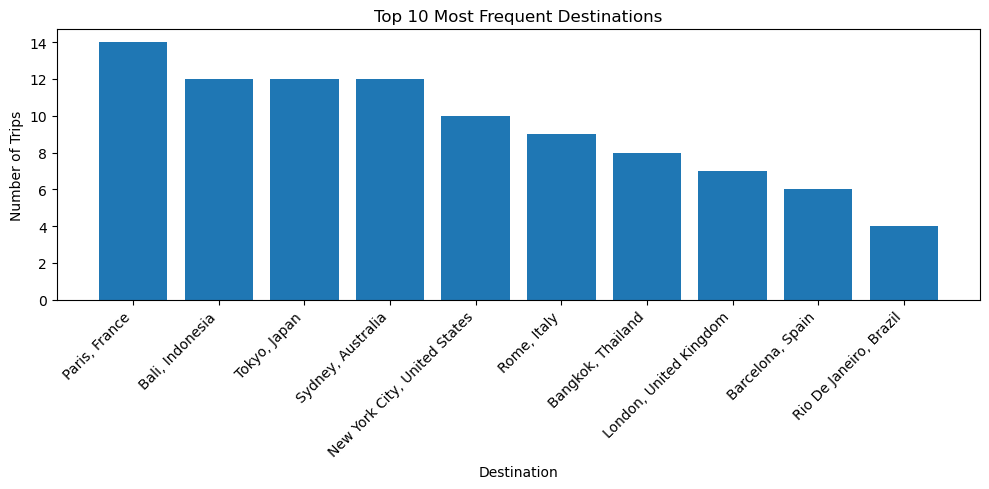

In [12]:
# ============================================================
# DESTINATION POPULARITY
# ============================================================

destination_counts = df["destination"].value_counts().reset_index()
destination_counts.columns = ["destination", "trip_count"]

display(destination_counts.head(10))

plt.figure(figsize=(10, 5))
plt.bar(destination_counts.head(10)["destination"], destination_counts.head(10)["trip_count"])
plt.title("Top 10 Most Frequent Destinations")
plt.xlabel("Destination")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,traveler_age_clean,duration_days_clean,total_trip_cost,accommodation_per_night,travel_month
count,139.000000,139.000000,139.000000,139.000000,139.000000
mean,33.143885,7.597122,1878.597122,173.860083,6.661871
std,7.098235,1.591278,1821.829689,199.708638,3.020591
min,20.000000,5.000000,100.000000,14.285714,1.000000
25%,28.000000,7.000000,1000.000000,78.461538,5.000000
50%,31.000000,7.000000,1400.000000,125.000000,7.000000
75%,37.500000,8.000000,1900.000000,175.714286,9.000000
max,60.000000,14.000000,10500.000000,1142.857143,12.000000


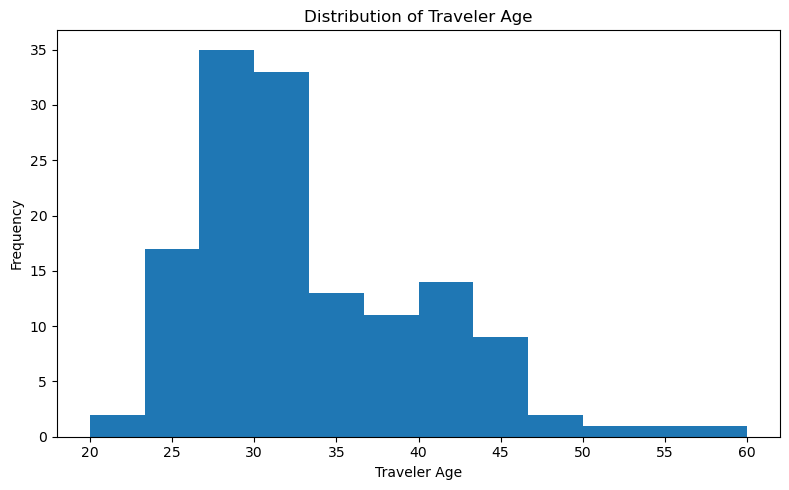

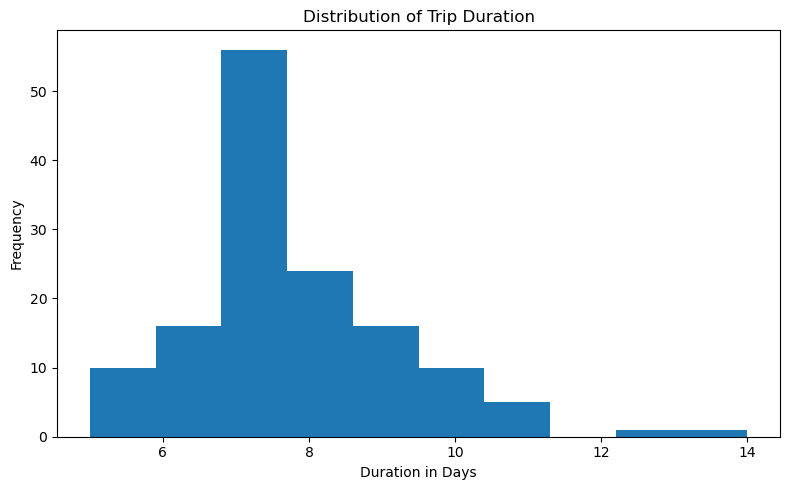

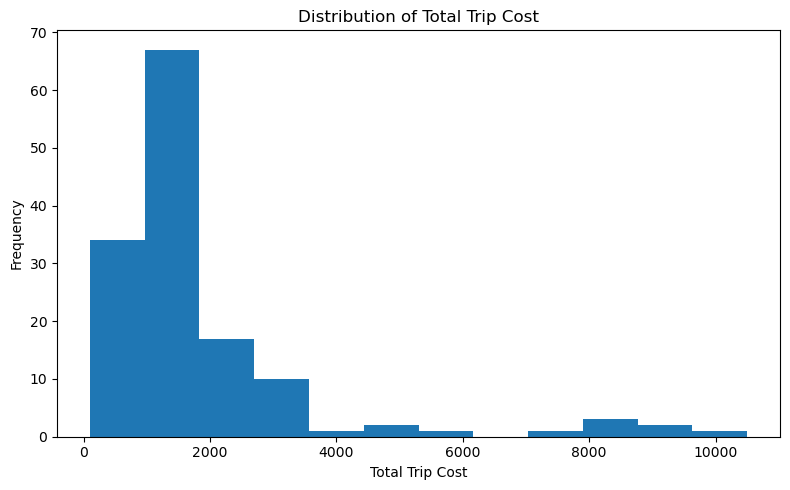

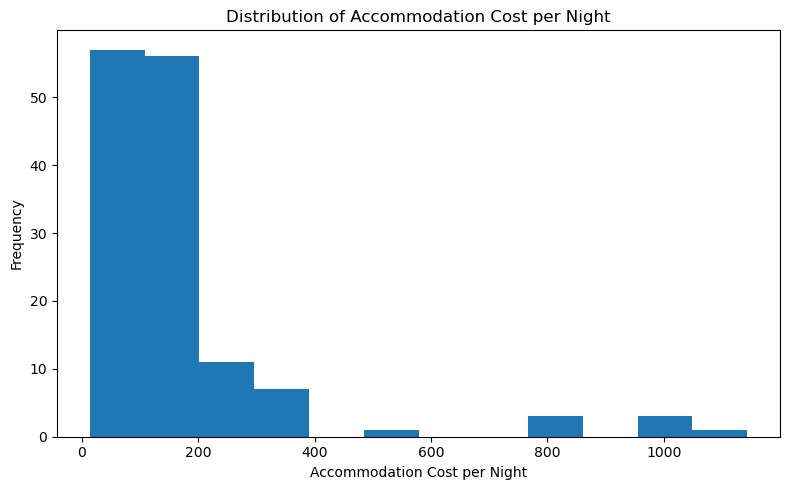

In [13]:
# ============================================================
# NUMERIC DISTRIBUTIONS
# ============================================================

summary_cols = [
    "traveler_age_clean",
    "duration_days_clean",
    "total_trip_cost",
    "accommodation_per_night",
    "travel_month"
]

display(df[summary_cols].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["traveler_age_clean"], bins=12)
plt.title("Distribution of Traveler Age")
plt.xlabel("Traveler Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["duration_days_clean"], bins=10)
plt.title("Distribution of Trip Duration")
plt.xlabel("Duration in Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["total_trip_cost"], bins=12)
plt.title("Distribution of Total Trip Cost")
plt.xlabel("Total Trip Cost")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["accommodation_per_night"], bins=12)
plt.title("Distribution of Accommodation Cost per Night")
plt.xlabel("Accommodation Cost per Night")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

,travel_month,trip_count
0,1,9
1,2,10
2,3,6
3,4,7
4,5,15
5,6,15
6,7,18
7,8,17
8,9,17
9,10,9


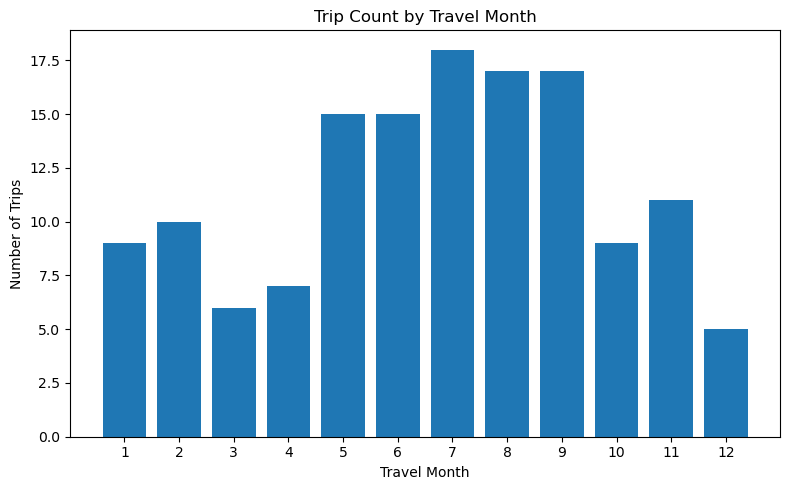

,accommodation_type,count
0,Hotel,60
1,Airbnb,30
2,Hostel,24
3,Resort,14
4,Villa,4
5,Vacation rental,3
6,Unknown,2
7,Riad,1
8,Guesthouse,1


,transportation_type,count
0,Plane,57
1,Train,37
2,Flight,13
3,Car rental,13
4,Bus,6
5,Airplane,5
6,Unknown,3
7,Car,3
8,Subway,1
9,Ferry,1


In [14]:
# ============================================================
# MONTH, ACCOMMODATION, AND TRANSPORTATION PATTERNS
# ============================================================

month_counts = df["travel_month"].value_counts().sort_index().reset_index()
month_counts.columns = ["travel_month", "trip_count"]
display(month_counts)

plt.figure(figsize=(8, 5))
plt.bar(month_counts["travel_month"], month_counts["trip_count"])
plt.title("Trip Count by Travel Month")
plt.xlabel("Travel Month")
plt.ylabel("Number of Trips")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

accommodation_counts = df["accommodation_type"].value_counts().reset_index()
accommodation_counts.columns = ["accommodation_type", "count"]
display(accommodation_counts)

transport_counts = df["transportation_type"].value_counts().reset_index()
transport_counts.columns = ["transportation_type", "count"]
display(transport_counts)

# 4. Destination Profile Engineering

The recommender ranks destinations, so the trip-level dataset is aggregated into a destination-level profile table.

Each destination profile contains:

- median traveler age
- median trip duration
- median total trip cost
- median accommodation cost per night
- common nationality
- common accommodation type
- common transportation type
- common travel month
- historical trip count

`season` is intentionally not used in this version. It is replaced by `travel_month`.

In [15]:
# ============================================================
# CREATE DESTINATION PROFILES
# ============================================================

destination_profiles = (
    df.groupby("destination")
    .agg(
        destination_city=("destination_city", mode_or_unknown),
        destination_country=("destination_country", mode_or_unknown),
        median_traveler_age=("traveler_age_clean", "median"),
        median_duration_days=("duration_days_clean", "median"),
        median_total_cost=("total_trip_cost", "median"),
        median_accommodation_per_night=("accommodation_per_night", "median"),
        common_nationality=("traveler_nationality", mode_or_unknown),
        common_accommodation=("accommodation_type", mode_or_unknown),
        common_transportation=("transportation_type", mode_or_unknown),
        common_travel_month=("travel_month", lambda x: int(pd.Series(x).mode().iloc[0]) if len(pd.Series(x).dropna()) else 1),
        trip_count=("destination", "size")
    )
    .reset_index()
)

# Popularity score scaled from 0 to 1
max_trip_count = destination_profiles["trip_count"].max()
destination_profiles["popularity_score"] = destination_profiles["trip_count"] / max_trip_count

display(destination_profiles.sort_values("trip_count", ascending=False).head(10))

,destination,destination_city,destination_country,median_traveler_age,median_duration_days,median_total_cost,median_accommodation_per_night,common_nationality,common_accommodation,common_transportation,common_travel_month,trip_count,popularity_score
29,"Paris, France",Paris,France,35.0,6.0,1600.0,177.380952,American,Hotel,Plane,6,14,1.000000
41,"Tokyo, Japan",Tokyo,Japan,28.0,8.5,1250.0,94.444444,American,Airbnb,Train,9,12,0.857143
5,"Bali, Indonesia",Bali,Indonesia,31.5,8.0,1850.0,139.610390,Korean,Resort,Plane,8,12,0.857143
39,"Sydney, Australia",Sydney,Australia,32.5,8.0,1550.0,107.142857,Australian,Hotel,Plane,11,12,0.857143
28,"New York City, United States",New York City,United States,30.0,6.5,1900.0,183.333333,American,Hotel,Car rental,7,10,0.714286
35,"Rome, Italy",Rome,Italy,33.0,7.0,1300.0,100.000000,Italian,Hotel,Train,7,9,0.642857
6,"Bangkok, Thailand",Bangkok,Thailand,31.0,7.5,675.0,53.571429,Indian,Hostel,Plane,9,8,0.571429
24,"London, United Kingdom",London,United Kingdom,35.0,7.0,1200.0,128.571429,British,Hotel,Train,3,7,0.500000
7,"Barcelona, Spain",Barcelona,Spain,30.0,7.0,1225.0,121.428571,Spanish,Airbnb,Plane,8,6,0.428571
34,"Rio De Janeiro, Brazil",Rio De Janeiro,Brazil,30.0,8.0,1700.0,150.000000,Brazilian,Airbnb,Car,1,4,0.285714


In [16]:
# ============================================================
# TEXT PROFILE FOR TF-IDF SIMILARITY
# ============================================================

def repeat_token(value, times=1):
    text = normalize_text(value)
    return " ".join([text] * times)

# Month is included as a text token, but the main month fit is handled numerically later.
destination_profiles["destination_text_profile"] = (
    destination_profiles["destination"].apply(lambda x: repeat_token(x, 3)) + " " +
    destination_profiles["destination_city"].apply(lambda x: repeat_token(x, 3)) + " " +
    destination_profiles["destination_country"].apply(lambda x: repeat_token(x, 3)) + " " +
    destination_profiles["common_nationality"].apply(lambda x: repeat_token(x, 2)) + " " +
    destination_profiles["common_accommodation"].apply(lambda x: repeat_token(x, 2)) + " " +
    destination_profiles["common_transportation"].apply(lambda x: repeat_token(x, 2)) + " " +
    destination_profiles["common_travel_month"].apply(lambda x: repeat_token(f"month_{int(x)}", 1))
)

display(destination_profiles[["destination", "destination_text_profile"]].head())

,destination,destination_text_profile
0,Amsterdam,amsterdam amsterdam amsterdam amsterdam amsterdam amsterdam unknown unknown unknown germany germany hotel hotel trai...
1,"Amsterdam, Netherlands",amsterdam netherlands amsterdam netherlands amsterdam netherlands amsterdam amsterdam amsterdam netherlands netherla...
2,"Athens, Greece",athens greece athens greece athens greece athens athens athens greece greece greece korean korean airbnb airbnb plan...
3,"Auckland, New Zealand",auckland new zealand auckland new zealand auckland new zealand auckland auckland auckland new zealand new zealand ne...
4,Australia,australia australia australia australia australia australia unknown unknown unknown british british hotel hotel car ...


# 5. Hybrid Recommendation Methodology

The final score combines multiple components:

```text
Final Score =
30% Profile Similarity
20% Budget Fit
15% Duration Fit
10% Accommodation per Night Fit
10% Preference Match
5% Month Fit
5% Popularity
5% Age Fit
```

## Score Components

**Profile Similarity**  
Uses TF-IDF and cosine similarity to compare the user's profile with destination profiles.

**Budget Fit**  
Measures how close the user's total budget is to the destination's historical median total trip cost.

**Duration Fit**  
Measures how close the user's desired duration is to the destination's median trip duration.

**Accommodation per Night Fit**  
Measures whether the user's implied accommodation budget per night fits the destination's historical accommodation cost per night.

**Preference Match**  
Checks accommodation type, transportation type, and preferred country.

**Month Fit**  
Uses circular month distance, so December and January are treated as close.

**Popularity**  
Adds confidence when a destination appears more frequently in the historical data.

**Age Fit**  
Compares the user age with the median age of travelers who visited the destination.

In [17]:
# ============================================================
# FIT TF-IDF MODEL
# ============================================================

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

destination_tfidf_matrix = tfidf.fit_transform(destination_profiles["destination_text_profile"])

print("TF-IDF matrix shape:", destination_tfidf_matrix.shape)

TF-IDF matrix shape: (44, 367)


In [18]:
# ============================================================
# RECOMMENDER HELPER FUNCTIONS
# ============================================================

def closeness_score(user_value, reference_value):
    """
    Returns a score from 0 to 1 based on how close user_value is to reference_value.
    Score is 1 when values are equal and approaches 0 as difference increases.
    """
    if pd.isna(user_value) or pd.isna(reference_value):
        return 0
    user_value = float(user_value)
    reference_value = float(reference_value)
    denominator = max(abs(user_value), abs(reference_value), 1)
    return max(0, 1 - (abs(user_value - reference_value) / denominator))


def month_similarity(user_month, destination_month):
    """
    Circular month similarity.
    December and January should be near each other, not far apart.
    """
    if pd.isna(user_month) or pd.isna(destination_month):
        return 0
    user_month = int(round(user_month))
    destination_month = int(round(destination_month))
    user_month = min(max(user_month, 1), 12)
    destination_month = min(max(destination_month, 1), 12)

    diff = abs(user_month - destination_month)
    circular_diff = min(diff, 12 - diff)
    return 1 - (circular_diff / 6)


def build_user_text_profile(
    nationality,
    accommodation_type,
    transportation_type,
    travel_month=1,
    preferred_country="Any"
):
    """Build user text profile for TF-IDF similarity."""
    return " ".join([
        repeat_token(nationality, 2),
        repeat_token(accommodation_type, 2),
        repeat_token(transportation_type, 2),
        repeat_token(f"month_{int(travel_month)}", 1),
        repeat_token(preferred_country, 3)
    ])


def preference_match_score(row, accommodation_type, transportation_type, preferred_country="Any"):
    """Preference match based on categorical user inputs."""
    score = 0
    components = 0

    components += 1
    if normalize_text(row["common_accommodation"]) == normalize_text(accommodation_type):
        score += 1

    components += 1
    if normalize_text(row["common_transportation"]) == normalize_text(transportation_type):
        score += 1

    if normalize_text(preferred_country) != "any":
        components += 1
        if normalize_text(row["destination_country"]) == normalize_text(preferred_country):
            score += 1

    return score / components if components > 0 else 0


def recommendation_comment(row):
    """Generate readable explanation for each recommendation."""
    reasons = []

    if row["profile_similarity"] >= 0.25:
        reasons.append("moderate to strong profile similarity")
    if row["budget_fit"] >= 0.80:
        reasons.append("strong budget fit")
    elif row["budget_fit"] >= 0.60:
        reasons.append("reasonable budget fit")
    if row["duration_fit"] >= 0.80:
        reasons.append("strong duration fit")
    if row["accommodation_per_night_fit"] >= 0.80:
        reasons.append("accommodation cost per night is aligned")
    if row["preference_match"] >= 0.67:
        reasons.append("matches most stated preferences")
    if row["month_fit"] >= 0.80:
        reasons.append(f"popular around month {int(row['common_travel_month'])}")
    if row["popularity_score"] >= 0.50:
        reasons.append("good historical support")

    if len(reasons) == 0:
        return "Recommended as a possible alternative, but fit is weaker than the top options."

    return "Recommended because of " + ", ".join(reasons) + "."

In [19]:
# ============================================================
# MAIN RECOMMENDER FUNCTION
# ============================================================

def recommend_getaways(
    age,
    gender,
    nationality,
    accommodation_type,
    transportation_type,
    duration_days,
    total_budget,
    accommodation_budget=None,
    travel_month=1,
    preferred_country="Any",
    top_n=5
):
    """
    Recommend destinations using hybrid scoring.

    Parameters
    ----------
    age : int or float
        Traveler age.
    gender : str
        Traveler gender. Included for user profile completeness but not directly weighted.
    nationality : str
        Traveler nationality.
    accommodation_type : str
        Preferred accommodation type.
    transportation_type : str
        Preferred transportation type.
    duration_days : int or float
        Desired trip duration.
    total_budget : int or float
        Total trip budget.
    accommodation_budget : int or float, optional
        Total accommodation budget. If None, the system estimates it as 60% of total_budget.
    travel_month : int
        Desired travel month from 1 to 12.
    preferred_country : str
        Optional preferred country. Use "Any" if no preference.
    top_n : int
        Number of recommendations to return.
    """

    # Estimate accommodation budget if not supplied
    if accommodation_budget is None:
        accommodation_budget = total_budget * 0.60

    user_accommodation_per_night = (
        accommodation_budget / duration_days if duration_days and duration_days > 0 else accommodation_budget
    )

    user_text = build_user_text_profile(
        nationality=nationality,
        accommodation_type=accommodation_type,
        transportation_type=transportation_type,
        travel_month=travel_month,
        preferred_country=preferred_country
    )

    user_vector = tfidf.transform([user_text])
    profile_similarity = cosine_similarity(user_vector, destination_tfidf_matrix).flatten()

    results = destination_profiles.copy()
    results["profile_similarity"] = profile_similarity

    results["budget_fit"] = results["median_total_cost"].apply(
        lambda x: closeness_score(total_budget, x)
    )

    results["duration_fit"] = results["median_duration_days"].apply(
        lambda x: closeness_score(duration_days, x)
    )

    results["age_fit"] = results["median_traveler_age"].apply(
        lambda x: closeness_score(age, x)
    )

    results["accommodation_per_night_fit"] = results["median_accommodation_per_night"].apply(
        lambda x: closeness_score(user_accommodation_per_night, x)
    )

    results["month_fit"] = results["common_travel_month"].apply(
        lambda x: month_similarity(travel_month, x)
    )

    results["preference_match"] = results.apply(
        lambda row: preference_match_score(
            row,
            accommodation_type=accommodation_type,
            transportation_type=transportation_type,
            preferred_country=preferred_country
        ),
        axis=1
    )

    # Final weighted score
    results["final_score"] = (
        0.30 * results["profile_similarity"] +
        0.20 * results["budget_fit"] +
        0.15 * results["duration_fit"] +
        0.10 * results["accommodation_per_night_fit"] +
        0.10 * results["preference_match"] +
        0.05 * results["month_fit"] +
        0.05 * results["popularity_score"] +
        0.05 * results["age_fit"]
    )

    results["recommendation_comment"] = results.apply(recommendation_comment, axis=1)

    output_columns = [
        "destination",
        "final_score",
        "profile_similarity",
        "budget_fit",
        "duration_fit",
        "accommodation_per_night_fit",
        "preference_match",
        "month_fit",
        "popularity_score",
        "age_fit",
        "median_total_cost",
        "median_duration_days",
        "median_accommodation_per_night",
        "common_accommodation",
        "common_transportation",
        "common_travel_month",
        "trip_count",
        "recommendation_comment"
    ]

    return (
        results[output_columns]
        .sort_values("final_score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

# 6. Sample Recommendation Output

This sample simulates a traveler looking for a 7-day trip with a moderate budget, hotel accommodation, flight transportation, and a preferred travel month.

In [21]:
# ============================================================
# SAMPLE RECOMMENDATION
# ============================================================

sample_recommendations = recommend_getaways(
    age=28,
    gender="Female",
    nationality="Filipino",
    accommodation_type="Hotel",
    transportation_type="Flight",
    duration_days=7,
    total_budget=1500,
    accommodation_budget=900,
    travel_month=6,
    preferred_country="Any",
    top_n=5
)

display(sample_recommendations)

,destination,final_score,profile_similarity,budget_fit,duration_fit,accommodation_per_night_fit,preference_match,month_fit,popularity_score,age_fit,median_total_cost,median_duration_days,median_accommodation_per_night,common_accommodation,common_transportation,common_travel_month,trip_count,recommendation_comment
0,"Paris, France",0.591868,0.044378,0.937500,0.857143,0.724832,0.5,1.000000,1.000000,0.800000,1600.0,6.0,177.380952,Hotel,Plane,6,14,"Recommended because of strong budget fit, strong duration fit, popular around month 6, good historical support."
1,"Berlin, Germany",0.584858,0.227587,0.714286,0.777778,0.826531,1.0,0.833333,0.071429,0.583333,2100.0,9.0,155.555556,Hotel,Flight,7,1,"Recommended because of reasonable budget fit, accommodation cost per night is aligned, matches most stated preferenc..."
2,"Los Angeles, United States",0.583907,0.029690,1.000000,1.000000,0.750000,0.5,1.000000,0.071429,0.928571,1500.0,7.0,171.428571,Hotel,Car rental,6,1,"Recommended because of strong budget fit, strong duration fit, popular around month 6."
3,"Rome, Italy",0.580422,0.043591,0.866667,1.000000,0.777778,0.5,0.833333,0.642857,0.848485,1300.0,7.0,100.000000,Hotel,Train,7,9,"Recommended because of strong budget fit, strong duration fit, popular around month 7, good historical support."
4,"Phuket, Thailand",0.573159,0.156257,0.933333,0.857143,0.989011,0.5,0.166667,0.142857,0.933333,1400.0,6.0,130.000000,Resort,Flight,1,2,"Recommended because of strong budget fit, strong duration fit, accommodation cost per night is aligned."


## Sample Output Interpretation

The recommendation output ranks destinations using the hybrid final score. A destination receives a high score when it is similar to the traveler profile, realistic for the budget, compatible with the preferred trip duration, aligned with accommodation cost per night, and close to the preferred travel month.

The `recommendation_comment` column makes the output easier to explain because it identifies the main reasons behind each recommendation.

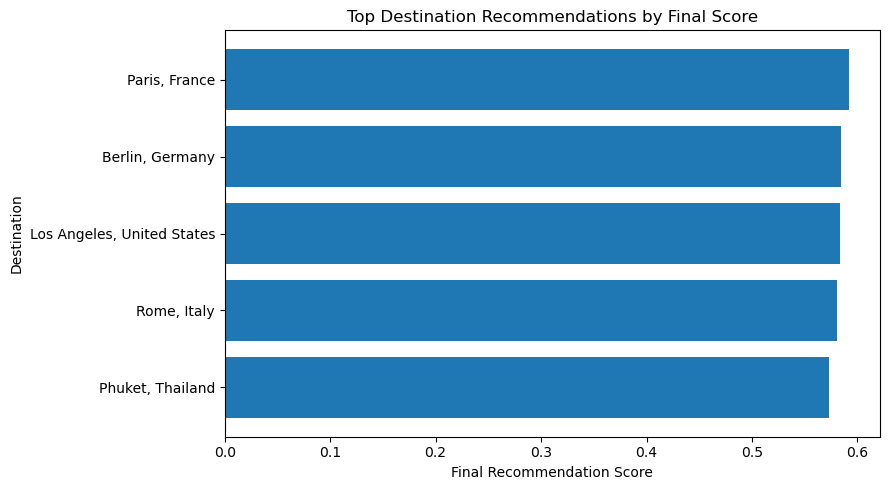

In [22]:
# ============================================================
# VISUALIZE RECOMMENDATION SCORES
# ============================================================

plot_data = sample_recommendations.sort_values("final_score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["destination"], plot_data["final_score"])
plt.title("Top Destination Recommendations by Final Score")
plt.xlabel("Final Recommendation Score")
plt.ylabel("Destination")
plt.tight_layout()
plt.show()

# 7. Evaluation

Since the dataset does not contain explicit ratings or satisfaction labels, RMSE is not appropriate. Instead, the recommender is evaluated using proxy metrics:

- average final score
- average profile similarity
- average budget fit
- average duration fit
- average accommodation per night fit
- average preference match
- average month fit
- catalog coverage at K
- country, accommodation, and transportation diversity

In [23]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

def evaluate_recommendations(recommendation_df, full_catalog):
    metrics = {
        "n_recommendations": len(recommendation_df),
        "coverage_at_k": recommendation_df["destination"].nunique() / full_catalog["destination"].nunique(),
        "country_diversity": recommendation_df["destination"].nunique(),
        "accommodation_diversity": recommendation_df["common_accommodation"].nunique(),
        "transportation_diversity": recommendation_df["common_transportation"].nunique(),
        "avg_final_score": recommendation_df["final_score"].mean(),
        "avg_profile_similarity": recommendation_df["profile_similarity"].mean(),
        "avg_budget_fit": recommendation_df["budget_fit"].mean(),
        "avg_duration_fit": recommendation_df["duration_fit"].mean(),
        "avg_accommodation_per_night_fit": recommendation_df["accommodation_per_night_fit"].mean(),
        "avg_preference_match": recommendation_df["preference_match"].mean(),
        "avg_month_fit": recommendation_df["month_fit"].mean(),
        "avg_popularity_score": recommendation_df["popularity_score"].mean()
    }

    return pd.DataFrame([metrics])

sample_eval = evaluate_recommendations(sample_recommendations, destination_profiles)
display(sample_eval)

,n_recommendations,coverage_at_k,country_diversity,accommodation_diversity,transportation_diversity,avg_final_score,avg_profile_similarity,avg_budget_fit,avg_duration_fit,avg_accommodation_per_night_fit,avg_preference_match,avg_month_fit,avg_popularity_score
0,5,0.113636,5,2,4,0.582843,0.100301,0.890357,0.898413,0.81363,0.6,0.766667,0.385714


## Evaluation Interpretation

The evaluation table summarizes the recommendation list quality.

A stronger recommendation list should have high final score, high budget fit, high duration fit, and high preference match. Diversity metrics help check whether the system recommends varied options rather than repeating the same type of destination.

In [24]:
# ============================================================
# QA TESTING ACROSS MULTIPLE TRAVELER PERSONAS
# ============================================================

test_profiles = [
    {
        "profile_name": "Budget Short Trip Traveler",
        "age": 23,
        "gender": "Male",
        "nationality": "American",
        "accommodation_type": "Hostel",
        "transportation_type": "Train",
        "duration_days": 3,
        "total_budget": 600,
        "accommodation_budget": 250,
        "travel_month": 4,
        "preferred_country": "Any"
    },
    {
        "profile_name": "Comfort International Traveler",
        "age": 35,
        "gender": "Female",
        "nationality": "Filipino",
        "accommodation_type": "Hotel",
        "transportation_type": "Flight",
        "duration_days": 7,
        "total_budget": 2000,
        "accommodation_budget": 1200,
        "travel_month": 6,
        "preferred_country": "Any"
    },
    {
        "profile_name": "Long Vacation Traveler",
        "age": 45,
        "gender": "Male",
        "nationality": "Canadian",
        "accommodation_type": "Resort",
        "transportation_type": "Flight",
        "duration_days": 12,
        "total_budget": 3500,
        "accommodation_budget": 2200,
        "travel_month": 12,
        "preferred_country": "Any"
    }
]

qa_results = []

for profile in test_profiles:
    recs = recommend_getaways(
        age=profile["age"],
        gender=profile["gender"],
        nationality=profile["nationality"],
        accommodation_type=profile["accommodation_type"],
        transportation_type=profile["transportation_type"],
        duration_days=profile["duration_days"],
        total_budget=profile["total_budget"],
        accommodation_budget=profile["accommodation_budget"],
        travel_month=profile["travel_month"],
        preferred_country=profile["preferred_country"],
        top_n=5
    )

    eval_df = evaluate_recommendations(recs, destination_profiles)
    eval_df.insert(0, "profile_name", profile["profile_name"])
    qa_results.append(eval_df)

qa_summary = pd.concat(qa_results, ignore_index=True)
display(qa_summary)

,profile_name,n_recommendations,coverage_at_k,country_diversity,accommodation_diversity,transportation_diversity,avg_final_score,avg_profile_similarity,avg_budget_fit,avg_duration_fit,avg_accommodation_per_night_fit,avg_preference_match,avg_month_fit,avg_popularity_score
0,Budget Short Trip Traveler,5,0.113636,5,2,3,0.455952,0.165134,0.717710,0.418095,0.634587,0.7,0.466667,0.185714
1,Comfort International Traveler,5,0.113636,5,1,3,0.591821,0.074476,0.860476,0.912698,0.939908,0.6,0.866667,0.428571
2,Long Vacation Traveler,5,0.113636,5,2,2,0.480325,0.151126,0.632381,0.666667,0.726595,0.7,0.333333,0.242857


## QA Testing Interpretation

The QA test checks whether the recommender adapts to different traveler personas. A good recommender should not return identical recommendations for all profiles.

If outputs become too similar across personas, a future improvement would be to reduce popularity weight, increase personalization weight, or add more traveler preference features.

# 8. Optional: Export Destination Profiles and Sample Results

These exports are useful if you want to use the cleaned destination profile table in a Streamlit app.

In [25]:
# ============================================================
# EXPORT OUTPUTS
# ============================================================

EXPORT_OUTPUTS = False

if EXPORT_OUTPUTS:
    destination_profiles.to_csv("wanderwise_destination_profiles.csv", index=False)
    sample_recommendations.to_csv("wanderwise_sample_recommendations.csv", index=False)
    print("Exported destination profiles and sample recommendations.")

# 9. Final Discussion

## Strengths

WanderWise is stronger than a simple popularity-based recommender because it considers both traveler preferences and practical constraints. The system uses destination similarity, budget fit, duration fit, accommodation per night, month fit, and preference matching.

The model is also interpretable because every recommendation includes score components and a short explanation.

## Limitations

The dataset does not contain explicit ratings, clicks, bookings, or satisfaction outcomes. Because of this, the model cannot directly validate whether the traveler actually liked the recommendation. The dataset is also relatively small, so some destination profiles may be based on limited historical records.

## Future Improvements

Future versions can include:

- user ratings or satisfaction labels
- attraction-level destination features
- weather and event data by month
- real-time flight and hotel price data
- diversity-aware re-ranking
- collaborative filtering if user-item interaction data becomes available
- Streamlit deployment

## Conclusion

This notebook demonstrates a complete hybrid recommender system workflow. It includes data cleaning, destination normalization, feature engineering, destination profile aggregation, TF-IDF similarity modeling, hybrid score ranking, output interpretation, and proxy evaluation.